# 데이터 확인 및 준비하기

In [1]:
# import os
# import random #데이터 샘플링
# from collections import Counter # count 용도

import numpy as np
import pandas as pd

from tqdm import tqdm

# 결측치 확인
import missingno as msno

import warnings
warnings.filterwarnings('ignore')

# 시각화
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.style.use('fivethirtyeight')

# 한글, 마이너스 깨짐 방지
from matplotlib import rc, font_manager, rcParams
font=font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family = font)
rcParams['axes.unicode_minus'] = False

# # 지도
# # from geopy import distance # 거리 계산
# # import geopy.distance
# import folium
# from folium.plugins import HeatMap

# # plotly
# import ipywidgets as widgets
# from ipywidgets import interact

# # 이걸 설정하면 Multiple Output이 가능함
# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = "all"

# import chart_studio.plotly as py 
# import plotly.express as px
# import cufflinks as cf 
# cf.go_offline(connected=True)

# import plotly.graph_objects as go

## 데이터 불러오기

In [3]:
df = pd.read_csv('./dataset/OBS_ASOS_DD_20220416221521.csv', encoding='utf-8')
df.head()

,지점,지점명,일시,평균기온(°C),최저기온(°C),최저기온 시각(hhmi),최고기온(°C),최고기온 시각(hhmi)
0,165,목포,2012-01-01,2.9,0.1,2245,6.1,1124.0
1,165,목포,2012-01-02,-0.3,-3.0,655,2.5,1319.0
2,165,목포,2012-01-03,0.2,-1.8,745,4.4,1241.0
3,165,목포,2012-01-04,-1.3,-3.3,538,0.7,1420.0
4,165,목포,2012-01-05,-1.0,-3.2,816,2.6,1349.0


In [4]:
df.shape

(49567, 8)

In [5]:
# 결측치 확인
df.isnull().sum()

지점                0
지점명               0
일시                0
평균기온(°C)         94
최저기온(°C)          1
최저기온 시각(hhmi)     0
최고기온(°C)          4
최고기온 시각(hhmi)     2
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49567 entries, 0 to 49566
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   지점             49567 non-null  int64  
 1   지점명            49567 non-null  object 
 2   일시             49567 non-null  object 
 3   평균기온(°C)       49473 non-null  float64
 4   최저기온(°C)       49566 non-null  float64
 5   최저기온 시각(hhmi)  49567 non-null  int64  
 6   최고기온(°C)       49563 non-null  float64
 7   최고기온 시각(hhmi)  49565 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 3.0+ MB


In [7]:
df[df['일시']=='2012-12-01']

,지점,지점명,일시,평균기온(°C),최저기온(°C),최저기온 시각(hhmi),최고기온(°C),최고기온 시각(hhmi)
335,165,목포,2012-12-01,2.9,-0.3,2200,6.0,32.0
3988,168,여수,2012-12-01,4.6,0.9,736,6.4,1513.0
7641,169,흑산도,2012-12-01,4.6,3.1,1140,8.2,28.0
11292,170,완도,2012-12-01,4.1,1.5,2244,8.1,1502.0
14943,174,순천,2012-12-01,1.5,-3.0,2203,8.1,1414.0
18596,175,진도(첨찰산),2012-12-01,0.8,-1.3,807,4.0,1323.0
21371,252,영광군,2012-12-01,0.6,-2.9,2348,5.4,1.0
25208,258,보성군,2012-12-01,3.1,-1.4,2141,8.6,1511.0
28861,259,강진군,2012-12-01,2.6,-1.7,2041,8.8,1350.0
32511,260,장흥,2012-12-01,2.8,-1.9,2103,8.8,1448.0


## 데이터 전처리

### 컬럼명 변경

In [10]:
df.rename(columns={'평균기온(°C)':'평균기온',
                   '최저기온(°C)':'최저기온',
                   '최고기온(°C)':'최고기온'}
         , inplace=True)
df

,지점,지점명,일시,평균기온,최저기온,최저기온 시각(hhmi),최고기온,최고기온 시각(hhmi)
0,165,목포,2012-01-01,2.9,0.1,2245,6.1,1124.0
1,165,목포,2012-01-02,-0.3,-3.0,655,2.5,1319.0
2,165,목포,2012-01-03,0.2,-1.8,745,4.4,1241.0
3,165,목포,2012-01-04,-1.3,-3.3,538,0.7,1420.0
4,165,목포,2012-01-05,-1.0,-3.2,816,2.6,1349.0
...,...,...,...,...,...,...,...,...
49562,268,진도군,2021-12-27,-3.0,-8.6,549,0.5,1546.0
49563,268,진도군,2021-12-28,1.4,-1.9,722,5.8,1330.0
49564,268,진도군,2021-12-29,5.3,-1.1,48,9.2,1459.0
49565,268,진도군,2021-12-30,3.8,1.6,2320,6.1,1539.0


In [11]:
df1 = df.groupby('일시')['평균기온', '최저기온', '최고기온'].mean()
df1 = df1.reset_index()
df1

,일시,평균기온,최저기온,최고기온
0,2012-01-01,2.164286,-0.950000,6.078571
1,2012-01-02,-0.271429,-3.992857,4.114286
2,2012-01-03,0.400000,-2.807143,4.635714
3,2012-01-04,-1.707143,-3.528571,0.335714
4,2012-01-05,-1.235714,-4.464286,2.992857
...,...,...,...,...
3648,2021-12-27,-1.946154,-7.738462,2.646154
3649,2021-12-28,2.884615,-1.438462,7.276923
3650,2021-12-29,4.800000,-0.146154,9.623077
3651,2021-12-30,2.915385,0.615385,5.607692


In [12]:
# 일시 컬럼 날짜 타입으로 변경
df1['일시'] = pd.to_datetime(df1['일시'])

In [13]:
# 년월, 월 컬럼 생성

# 년월
df1['년월'] = df1['일시'].dt.strftime('%Y-%m')
# 월
df1['월'] = df1['일시'].dt.strftime('%m')

df1.head()

,일시,평균기온,최저기온,최고기온,년월,월
0,2012-01-01,2.164286,-0.950000,6.078571,2012-01,01
1,2012-01-02,-0.271429,-3.992857,4.114286,2012-01,01
2,2012-01-03,0.400000,-2.807143,4.635714,2012-01,01
3,2012-01-04,-1.707143,-3.528571,0.335714,2012-01,01
4,2012-01-05,-1.235714,-4.464286,2.992857,2012-01,01


In [14]:
df2 = df1.groupby('년월')['평균기온', '최저기온', '최고기온'].mean()
df2 = df2.reset_index()
df2.head()

,년월,평균기온,최저기온,최고기온
0,2012-01,0.807373,-3.111290,5.237097
1,2012-02,0.537192,-3.349507,5.062315
2,2012-03,6.212903,1.948618,10.954378
3,2012-04,12.389524,7.029762,17.882619
4,2012-05,18.368398,13.573733,24.192272


In [39]:
df2['년월'] = pd.to_datetime(df2['년월'])
df2['월'] = df2['년월'].dt.month
df2['년월'] = df2['년월'].dt.strftime('%Y-%m')
df2

,년월,평균기온(°C),최저기온(°C),최고기온(°C),월
0,2012-12,1.444417,-2.361538,5.608933,12
1,2013-01,0.652854,-3.363027,5.113151,1
2,2013-02,2.374725,-1.940110,6.986264,2
3,2013-03,7.082630,1.300744,13.758809,3
4,2013-04,10.622821,5.184615,16.343333,4
...,...,...,...,...,...
107,2021-11,10.296154,5.505641,16.116410,11
108,2021-12,4.315881,-0.321588,9.648139,12
109,2022-01,1.872002,-2.288337,6.771464,1
110,2022-02,2.004281,-2.671223,7.068864,2


In [40]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   년월        112 non-null    object 
 1   평균기온(°C)  112 non-null    float64
 2   최저기온(°C)  112 non-null    float64
 3   최고기온(°C)  112 non-null    float64
 4   월         112 non-null    int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 4.5+ KB


In [69]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/a10.csv',
parse_dates=['date'], index_col='date')
df

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869
...,...
2008-02-01,21.654285
2008-03-01,18.264945
2008-04-01,23.107677


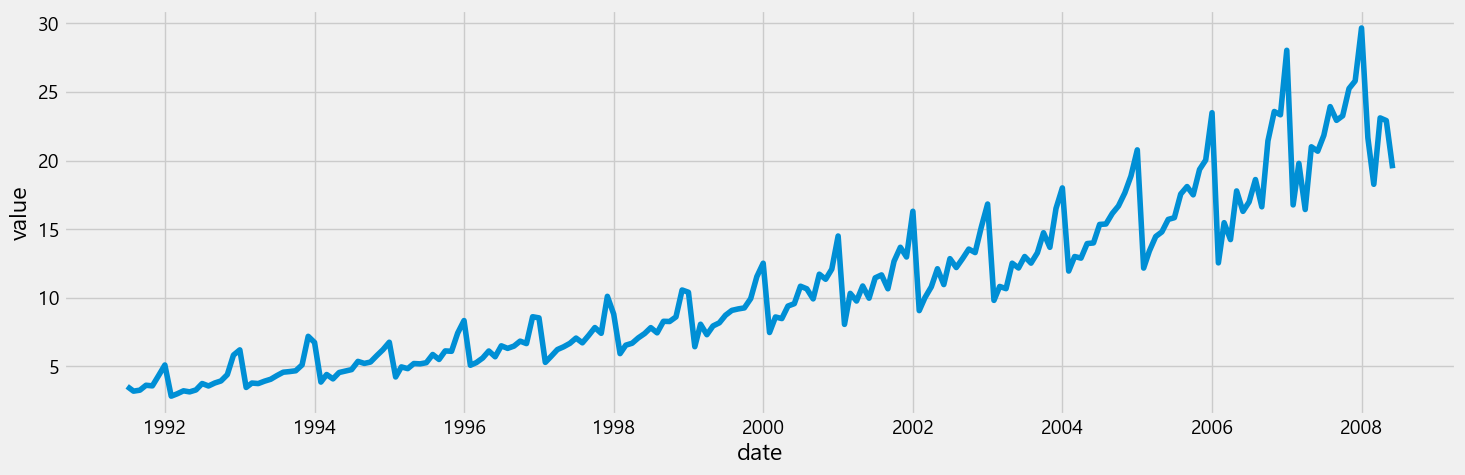

In [73]:
plt.figure(figsize=(16, 5), dpi=100)
sns.lineplot(x=df.index, y=df.value)
plt.show()

In [50]:
df = pd.read_csv('./dataset/OBS_ASOS_DD_20220410004008.csv',parse_dates=['일시'], index_col='일시', encoding='utf-8')
df.head()

,지점,지점명,평균기온(°C),최저기온(°C),최저기온 시각(hhmi),최고기온(°C),최고기온 시각(hhmi)
일시,,,,,,,
2012-12-01,165,목포,2.9,-0.3,2200,6.0,32
2012-12-02,165,목포,4.8,0.3,1,10.4,1507
2012-12-03,165,목포,5.0,1.4,514,10.4,1438
2012-12-04,165,목포,3.0,0.9,2239,6.1,1257
2012-12-05,165,목포,3.0,-0.3,2204,8.0,1240


In [21]:
df = pd.read_csv('./dataset/OBS_ASOS_DD_20220416221521.csv', parse_dates=['일시'], encoding='utf-8')
df.head()

,지점,지점명,일시,평균기온(°C),최저기온(°C),최저기온 시각(hhmi),최고기온(°C),최고기온 시각(hhmi)
0,165,목포,2012-01-01,2.9,0.1,2245,6.1,1124.0
1,165,목포,2012-01-02,-0.3,-3.0,655,2.5,1319.0
2,165,목포,2012-01-03,0.2,-1.8,745,4.4,1241.0
3,165,목포,2012-01-04,-1.3,-3.3,538,0.7,1420.0
4,165,목포,2012-01-05,-1.0,-3.2,816,2.6,1349.0


In [23]:
df1 = df.groupby('일시')['평균기온(°C)', '최저기온(°C)', '최고기온(°C)'].mean()
df1.columns=['평균기온', '최저기온', '최고기온']
df1

,평균기온,최저기온,최고기온
일시,,,
2012-01-01,2.164286,-0.950000,6.078571
2012-01-02,-0.271429,-3.992857,4.114286
2012-01-03,0.400000,-2.807143,4.635714
2012-01-04,-1.707143,-3.528571,0.335714
2012-01-05,-1.235714,-4.464286,2.992857
...,...,...,...
2021-12-27,-1.946154,-7.738462,2.646154
2021-12-28,2.884615,-1.438462,7.276923
2021-12-29,4.800000,-0.146154,9.623077


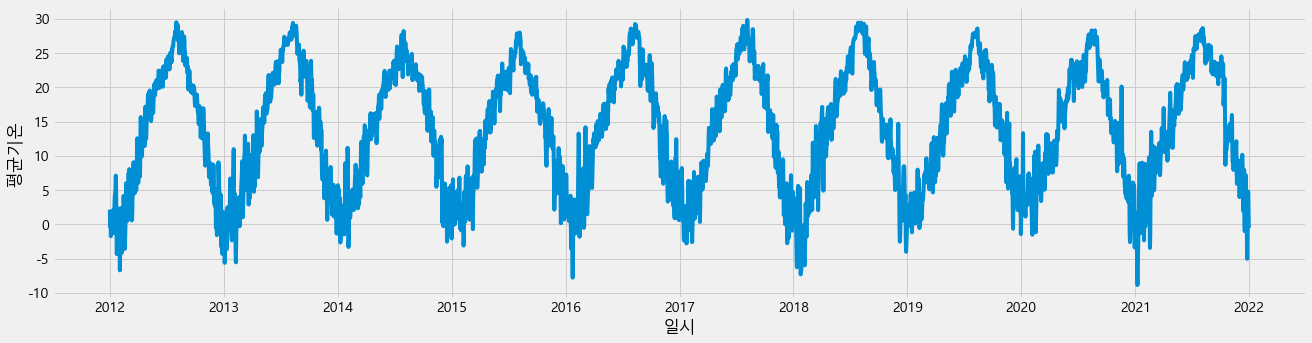

In [24]:
plt.figure(figsize=(20,5))
sns.lineplot(x=df1.index, y=df1['평균기온'], data=df1)
plt.show()

In [25]:
df1 = df1.reset_index()
df1['year'] = df1['일시'].dt.year
df1['month'] = df1['일시'].dt.month
df1

,일시,평균기온,최저기온,최고기온,year,month
0,2012-01-01,2.164286,-0.950000,6.078571,2012,1
1,2012-01-02,-0.271429,-3.992857,4.114286,2012,1
2,2012-01-03,0.400000,-2.807143,4.635714,2012,1
3,2012-01-04,-1.707143,-3.528571,0.335714,2012,1
4,2012-01-05,-1.235714,-4.464286,2.992857,2012,1
...,...,...,...,...,...,...
3648,2021-12-27,-1.946154,-7.738462,2.646154,2021,12
3649,2021-12-28,2.884615,-1.438462,7.276923,2021,12
3650,2021-12-29,4.800000,-0.146154,9.623077,2021,12
3651,2021-12-30,2.915385,0.615385,5.607692,2021,12


In [26]:
years = df1['year'].unique()
years

array([2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021],
      dtype=int64)

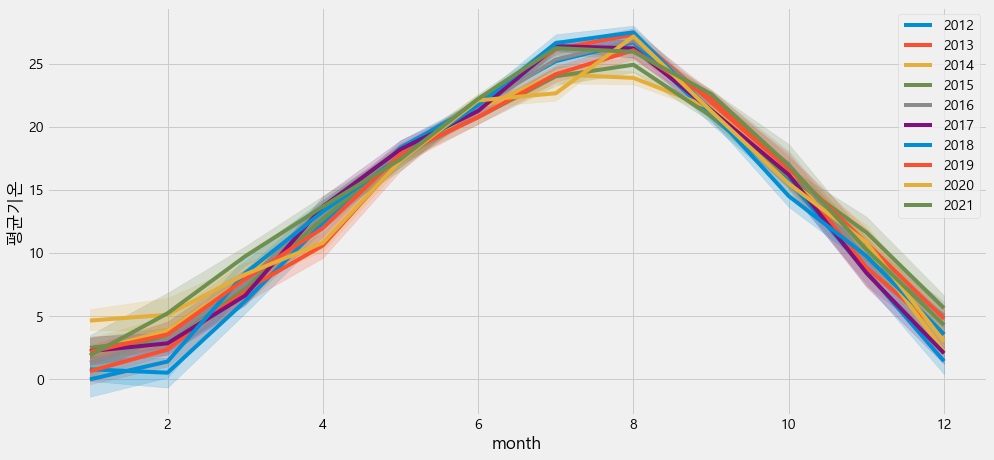

In [27]:
plt.figure(figsize=(15, 7))
for i, y in enumerate(years):
    sns.lineplot('month', '평균기온', data=df1[df1.year==y], label=y)
    
plt.show()

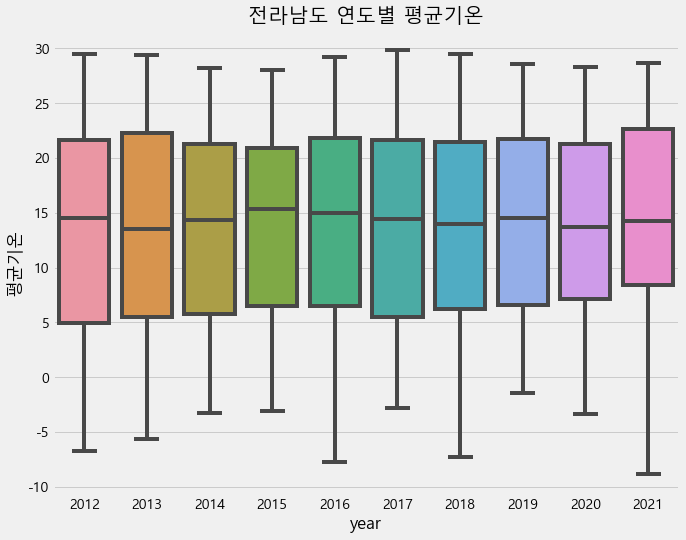

In [48]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='평균기온', data=df1)
plt.title('전라남도 연도별 평균기온')
plt.show()

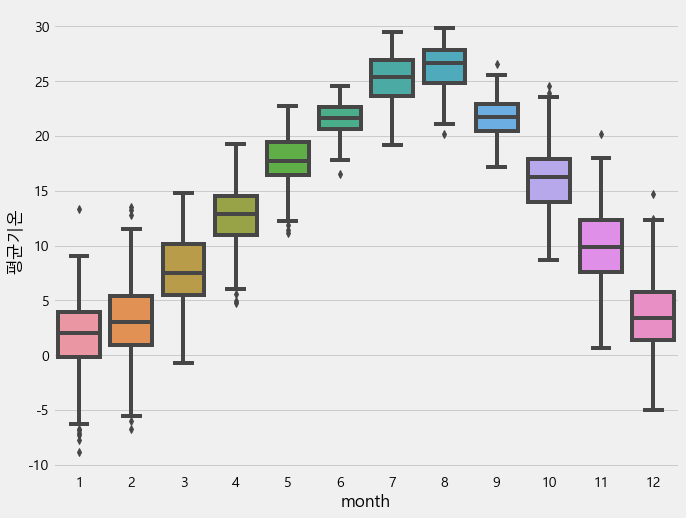

In [29]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='month', y='평균기온', data=df1)
plt.show()

In [30]:
df1

,일시,평균기온,최저기온,최고기온,year,month
0,2012-01-01,2.164286,-0.950000,6.078571,2012,1
1,2012-01-02,-0.271429,-3.992857,4.114286,2012,1
2,2012-01-03,0.400000,-2.807143,4.635714,2012,1
3,2012-01-04,-1.707143,-3.528571,0.335714,2012,1
4,2012-01-05,-1.235714,-4.464286,2.992857,2012,1
...,...,...,...,...,...,...
3648,2021-12-27,-1.946154,-7.738462,2.646154,2021,12
3649,2021-12-28,2.884615,-1.438462,7.276923,2021,12
3650,2021-12-29,4.800000,-0.146154,9.623077,2021,12
3651,2021-12-30,2.915385,0.615385,5.607692,2021,12


## 12월

In [31]:
df2 = df1[df1['month']==12]
df2

,일시,평균기온,최저기온,최고기온,year,month
335,2012-12-01,2.953846,-0.846154,7.530769,2012,12
336,2012-12-02,5.038462,0.607692,10.553846,2012,12
337,2012-12-03,5.184615,-0.030769,10.500000,2012,12
338,2012-12-04,2.592308,0.038462,5.876923,2012,12
339,2012-12-05,2.976923,-0.876923,8.661538,2012,12
...,...,...,...,...,...,...
3648,2021-12-27,-1.946154,-7.738462,2.646154,2021,12
3649,2021-12-28,2.884615,-1.438462,7.276923,2021,12
3650,2021-12-29,4.800000,-0.146154,9.623077,2021,12
3651,2021-12-30,2.915385,0.615385,5.607692,2021,12


### 평균기온

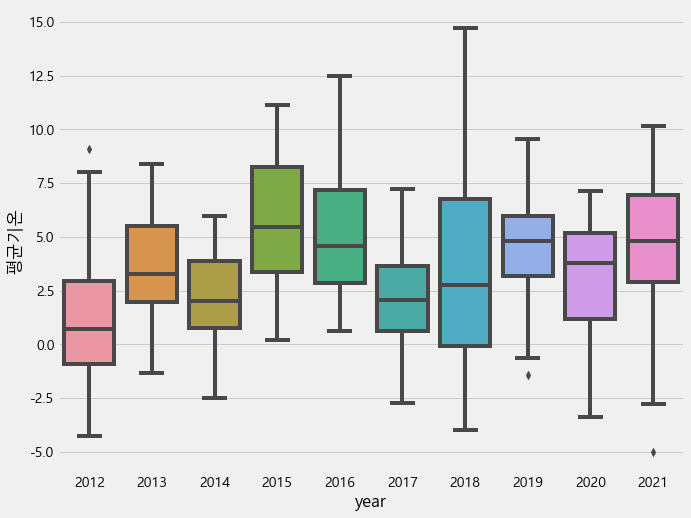

In [32]:
# 12월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='평균기온', data=df2)
plt.show()

### 최저기온

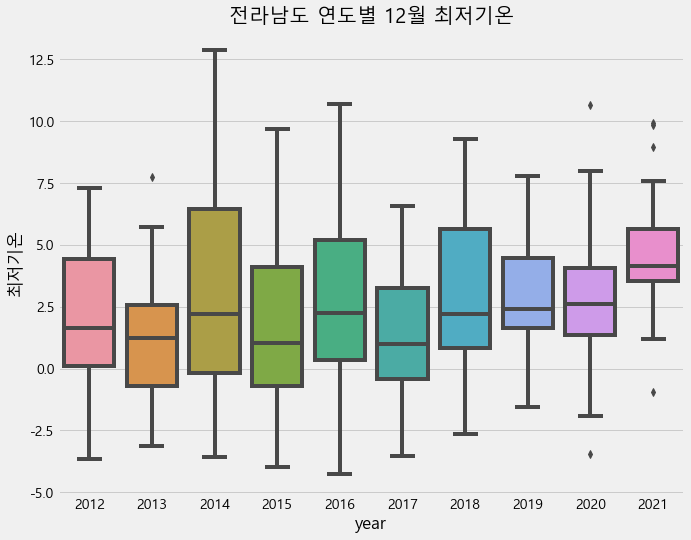

In [55]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='최저기온', data=df2)
plt.title('전라남도 연도별 12월 최저기온')
plt.show()

### 최고기온

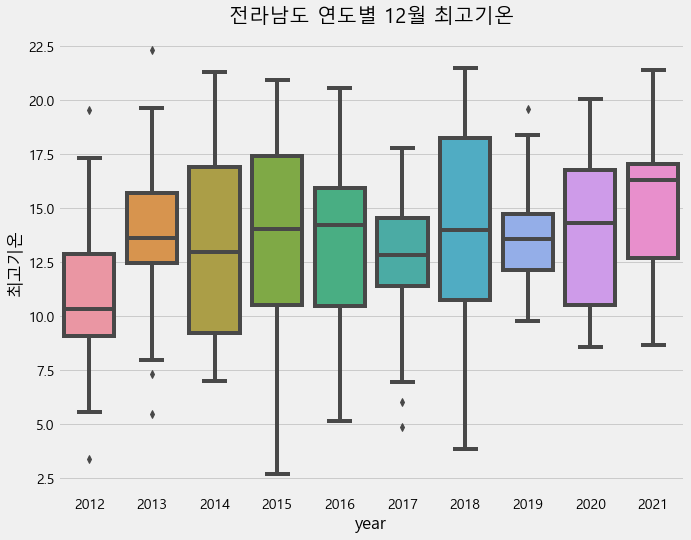

In [54]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='최고기온', data=df2)
plt.title('전라남도 연도별 12월 최고기온')
plt.show()

## 1월

In [35]:
df2 = df1[df1['month']==1]
df2

,일시,평균기온,최저기온,최고기온,year,month
0,2012-01-01,2.164286,-0.950000,6.078571,2012,1
1,2012-01-02,-0.271429,-3.992857,4.114286,2012,1
2,2012-01-03,0.400000,-2.807143,4.635714,2012,1
3,2012-01-04,-1.707143,-3.528571,0.335714,2012,1
4,2012-01-05,-1.235714,-4.464286,2.992857,2012,1
...,...,...,...,...,...,...
3314,2021-01-27,4.784615,0.476923,10.038462,2021,1
3315,2021-01-28,1.307692,-3.392308,8.938462,2021,1
3316,2021-01-29,-2.323077,-5.215385,1.530769,2021,1
3317,2021-01-30,2.323077,-5.184615,10.076923,2021,1


### 평균기온

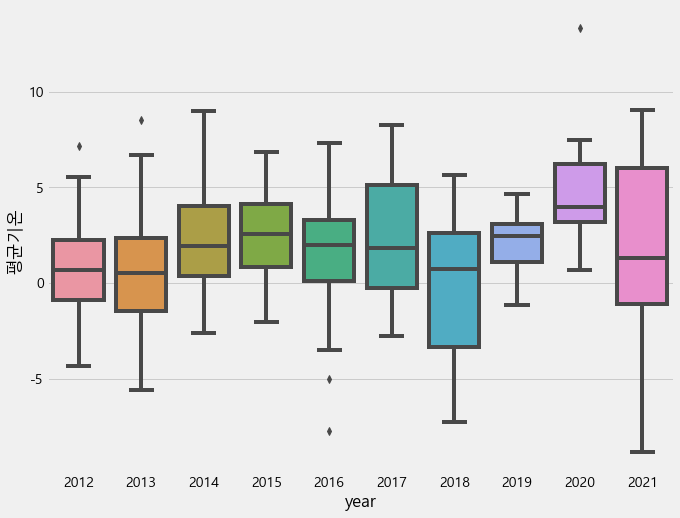

In [36]:
# 1월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='평균기온', data=df2)
plt.show()

### 최저기온

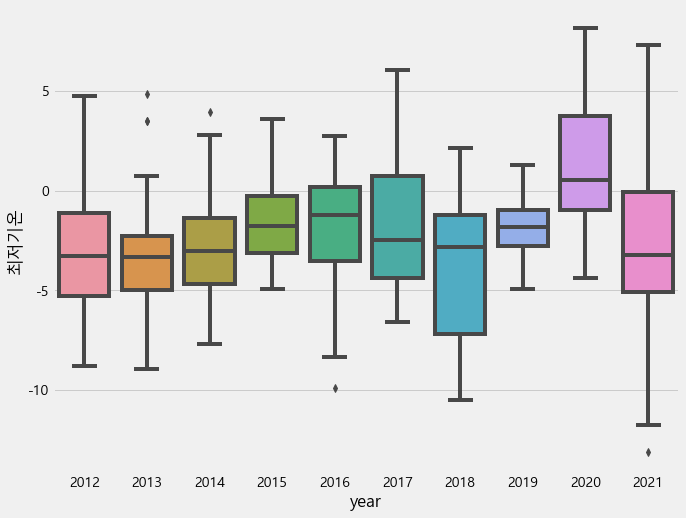

In [37]:
# 1월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='최저기온', data=df2)
plt.show()

### 최고기온

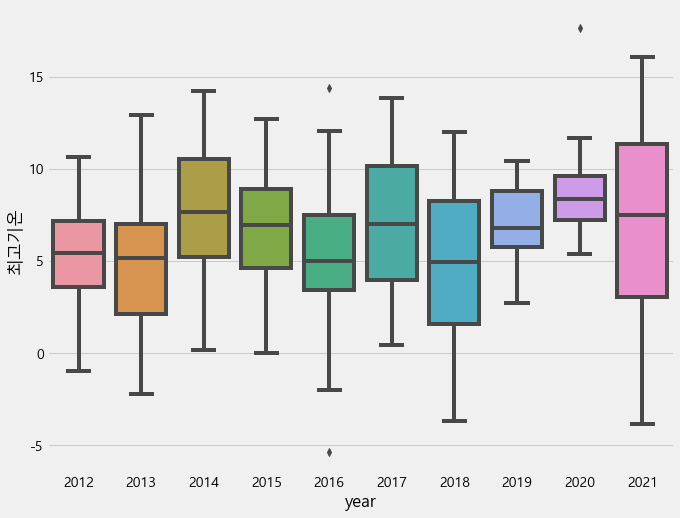

In [38]:
# 1월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='최고기온', data=df2)
plt.show()

## 2월

In [39]:
df2 = df1[df1['month']==2]
df2.head()

,일시,평균기온,최저기온,최고기온,year,month
31,2012-02-01,-2.942857,-6.071429,3.750000,2012,2
32,2012-02-02,-6.700000,-9.200000,-3.764286,2012,2
33,2012-02-03,-3.978571,-9.278571,1.307143,2012,2
34,2012-02-04,0.021429,-5.321429,6.035714,2012,2
35,2012-02-05,0.342857,-3.542857,4.150000,2012,2


### 평균기온

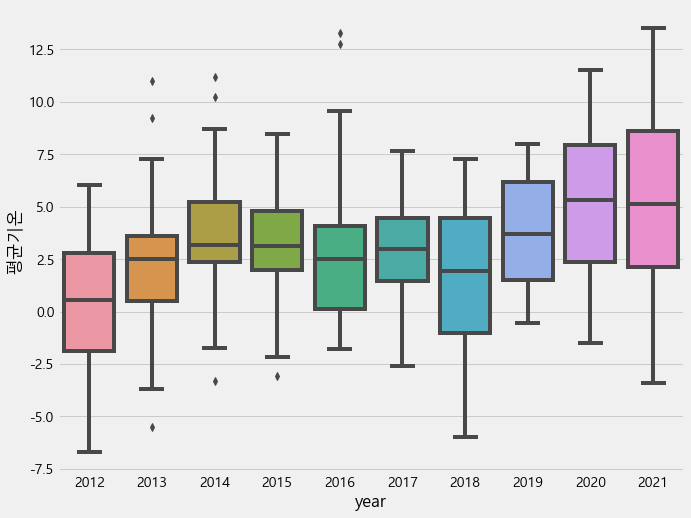

In [40]:
# 2월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='평균기온', data=df2)
plt.show()

### 최저기온

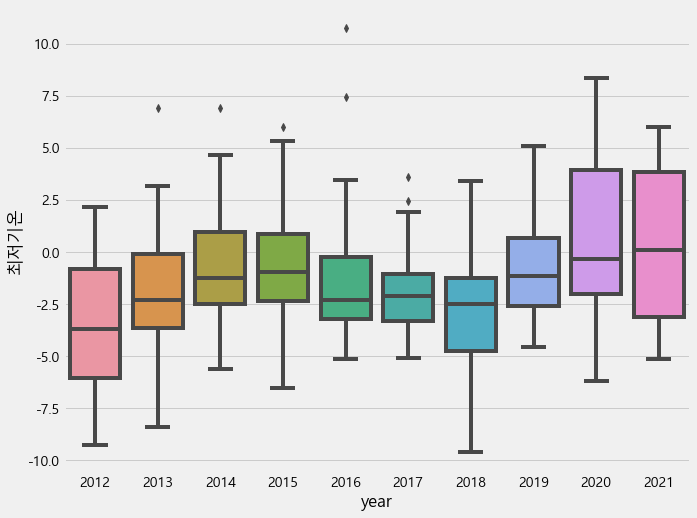

In [41]:
# 2월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='최저기온', data=df2)
plt.show()

### 최고기온

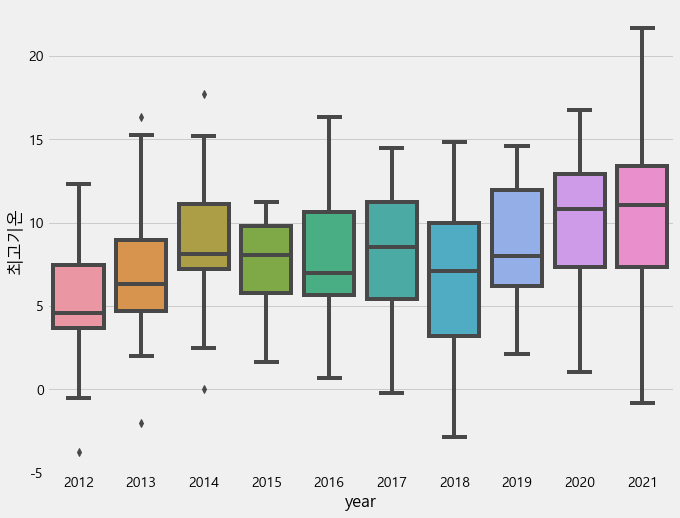

In [42]:
# 2월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='최고기온', data=df2)
plt.show()

## 3월

In [43]:
df2 = df1[df1['month']==3]
df2.head()

,일시,평균기온,최저기온,최고기온,year,month
60,2012-03-01,7.514286,1.650000,14.342857,2012,3
61,2012-03-02,5.871429,4.621429,7.750000,2012,3
62,2012-03-03,8.078571,4.621429,12.971429,2012,3
63,2012-03-04,6.671429,4.885714,9.042857,2012,3
64,2012-03-05,6.371429,5.342857,7.392857,2012,3


### 평균기온

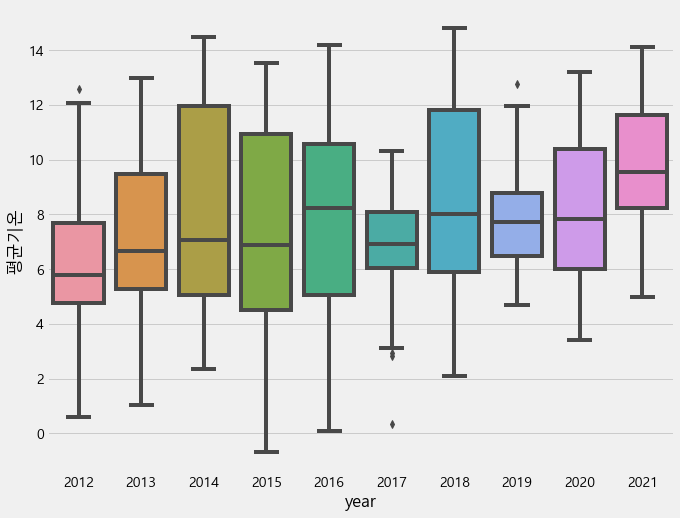

In [44]:
# 3월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='평균기온', data=df2)
plt.show()

### 최저기온

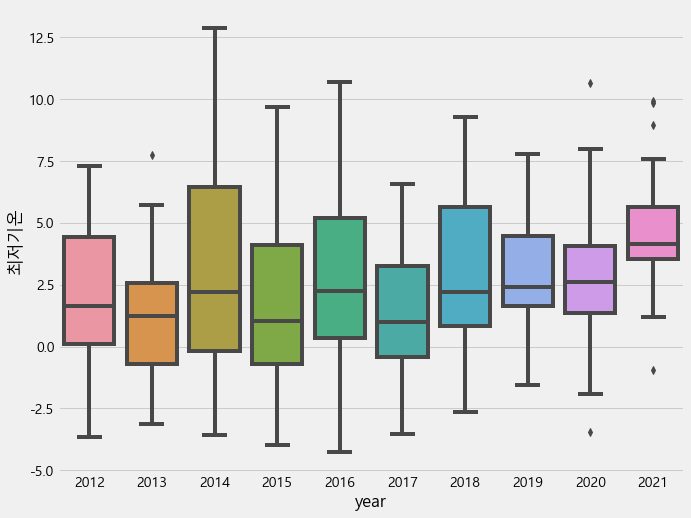

In [45]:
# 3월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='최저기온', data=df2)
plt.show()

### 최고기온

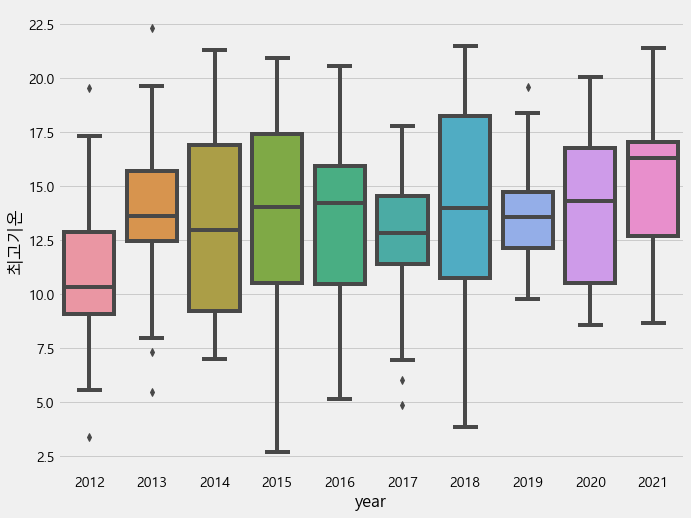

In [46]:
# 3월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='최고기온', data=df2)
plt.show()

In [49]:
df1

,일시,평균기온,최저기온,최고기온,year,month
0,2012-01-01,2.164286,-0.950000,6.078571,2012,1
1,2012-01-02,-0.271429,-3.992857,4.114286,2012,1
2,2012-01-03,0.400000,-2.807143,4.635714,2012,1
3,2012-01-04,-1.707143,-3.528571,0.335714,2012,1
4,2012-01-05,-1.235714,-4.464286,2.992857,2012,1
...,...,...,...,...,...,...
3648,2021-12-27,-1.946154,-7.738462,2.646154,2021,12
3649,2021-12-28,2.884615,-1.438462,7.276923,2021,12
3650,2021-12-29,4.800000,-0.146154,9.623077,2021,12
3651,2021-12-30,2.915385,0.615385,5.607692,2021,12


In [ ]:
plt.figure(figsize=(15, 7))
for i, y in enumerate(years):
    sns.lineplot('month', '평균기온', data=df1[df1.year==y], label=y)
    
plt.show()

## 데이터 저장하기

In [51]:
# df1.to_csv('./dataset/날씨_전처리 완료.csv', index=False)